# Testing Markov Decision Process (MDP) Environment

This notebook demonstrates the key features of the MDP environment with tests for:

1. Basic state transitions
2. Observational vs interventional policies
3. Reward accumulation
4. Multi-step episodes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from causal_gym.envs import MDPPCH
import warnings
warnings.filterwarnings("ignore", category=UserWarning,
                      message="Overriding environment .* already in registry")

In [2]:
# Parameters
N_EPISODES = 100
HORIZON = 20  # Maximum steps per episode

In [3]:
def run_observational(env, n_episodes, horizon):
    """Run episodes under observational policy"""
    total_rewards = []
    trajectories = []
    print("Running Observational...")
    
    for ep in range(n_episodes):
        if (ep + 1) % (n_episodes // 10) == 0:
            print(f"  Episode {ep + 1}/{n_episodes}")
        
        env.reset()
        episode_reward = 0
        trajectory = []
        
        for step in range(horizon):
            obs, reward, term, _, info = env.see()
            episode_reward += reward
            trajectory.append((obs, info['natural_action'], reward))
            if term:
                break
                
        total_rewards.append(episode_reward)
        trajectories.append(trajectory)
        
    print("Finished observational run.")
    return total_rewards, trajectories

def run_interventional(env, n_episodes, horizon, policy):
    """Run episodes with a fixed policy"""
    total_rewards = []
    trajectories = []
    print(f"Running Interventional...")
    
    for ep in range(n_episodes):
        if (ep + 1) % (n_episodes // 10) == 0:
            print(f"  Episode {ep + 1}/{n_episodes}")
            
        obs, _ = env.reset()
        episode_reward = 0
        trajectory = []
        
        for step in range(horizon):
            # action = policy(obs)
            obs, reward, term, _, info = env.do(policy)
            episode_reward += reward
            trajectory.append((obs, info['action'], reward))
            if term:
                break
                
        total_rewards.append(episode_reward)
        trajectories.append(trajectory)
        
    print("Finished interventional run.")
    return total_rewards, trajectories

## Test 1: Basic State Transitions

Let's first test the basic state transition dynamics of the MDP.

Running Observational...
  Episode 10/100
  Episode 20/100
  Episode 30/100
  Episode 40/100
  Episode 50/100
  Episode 60/100
  Episode 70/100
  Episode 80/100
  Episode 90/100
  Episode 100/100
Finished observational run.

Observational Results:
Average episode reward: 1.940
Average episode length: 20.0 steps


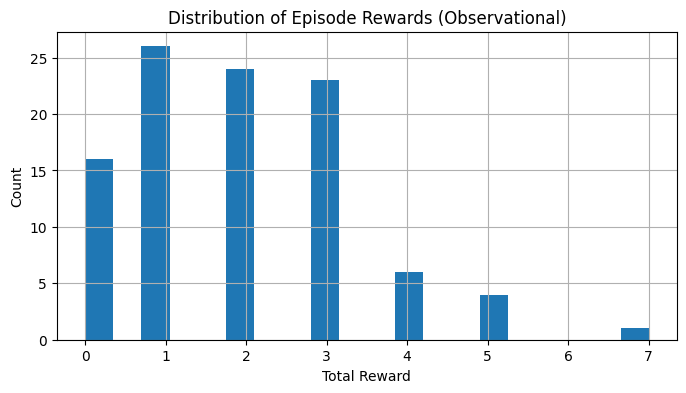

In [4]:
# Create environment
env = MDPPCH()

# Run observational policy
obs_rewards, obs_trajs = run_observational(env, N_EPISODES, HORIZON)

print("\nObservational Results:")
print(f"Average episode reward: {np.mean(obs_rewards):.3f}")
print(f"Average episode length: {np.mean([len(t) for t in obs_trajs]):.1f} steps")

# Plot reward distribution
plt.figure(figsize=(8, 4))
plt.hist(obs_rewards, bins=20)
plt.title('Distribution of Episode Rewards (Observational)')
plt.xlabel('Total Reward')
plt.ylabel('Count')
plt.grid(True)
plt.show()

## Test 2: Different Policies

Now let's compare different intervention policies.

Running Interventional...
  Episode 10/100
  Episode 20/100
  Episode 30/100
  Episode 40/100
  Episode 50/100
  Episode 60/100
  Episode 70/100
  Episode 80/100
  Episode 90/100
  Episode 100/100
Finished interventional run.

Action 0 Policy Results:
Average episode reward: 9.930
Average episode length: 20.0 steps
Running Interventional...
  Episode 10/100
  Episode 20/100
  Episode 30/100
  Episode 40/100
  Episode 50/100
  Episode 60/100
  Episode 70/100
  Episode 80/100
  Episode 90/100
  Episode 100/100
Finished interventional run.

Action 1 Policy Results:
Average episode reward: 6.540
Average episode length: 20.0 steps
Running Interventional...
  Episode 10/100
  Episode 20/100
  Episode 30/100
  Episode 40/100
  Episode 50/100
  Episode 60/100
  Episode 70/100
  Episode 80/100
  Episode 90/100
  Episode 100/100
Finished interventional run.

Random Policy Results:
Average episode reward: 9.840
Average episode length: 20.0 steps


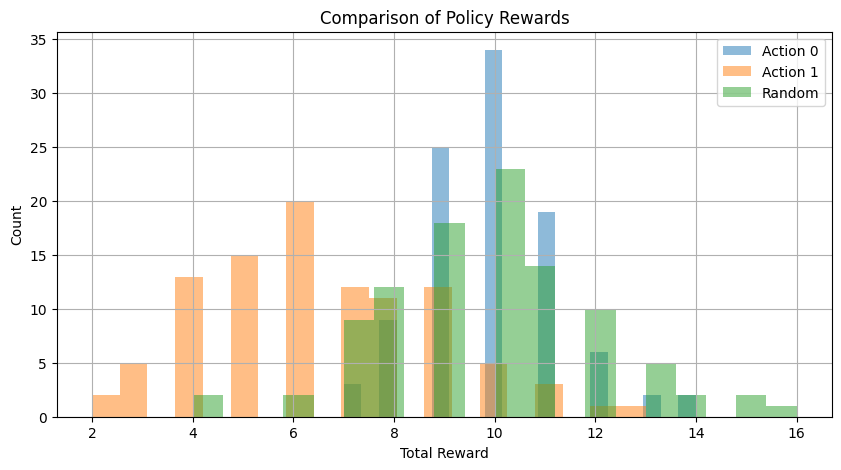

In [5]:
# Define some simple policies
def always_action_0(state=None):
    return 0

def always_action_1(state=None):
    return 1

def random_policy(state=None):
    return np.random.choice([0, 1])

# Test each policy
policies = {
    'Action 0': always_action_0,
    'Action 1': always_action_1,
    'Random': random_policy
}

results = {}
for name, policy in policies.items():
    rewards, trajs = run_interventional(env, N_EPISODES, HORIZON, policy)
    results[name] = {
        'rewards': rewards,
        'trajectories': trajs
    }
    print(f"\n{name} Policy Results:")
    print(f"Average episode reward: {np.mean(rewards):.3f}")
    print(f"Average episode length: {np.mean([len(t) for t in trajs]):.1f} steps")

# Plot comparison
plt.figure(figsize=(10, 5))
for name, data in results.items():
    plt.hist(data['rewards'], alpha=0.5, label=name, bins=20)
plt.title('Comparison of Policy Rewards')
plt.xlabel('Total Reward')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()

## Test 3: Analyzing State Transitions

Let's look at the state transition patterns.

In [6]:
def analyze_transitions(trajectories):
    """Analyze state transitions from trajectories"""
    transitions = {}
    for traj in trajectories:
        for i in range(len(traj)-1):
            state = traj[i][0]
            action = traj[i][1]
            next_state = traj[i+1][0]
            key = (state, action)
            if key not in transitions:
                transitions[key] = []
            transitions[key].append(next_state)
    return transitions

# Analyze transitions for each policy
for name, data in results.items():
    transitions = analyze_transitions(data['trajectories'])
    print(f"\nTransition Analysis for {name} Policy:")
    for (state, action), next_states in transitions.items():
        print(f"State {state}, Action {action} -> Next states: {np.unique(next_states)}")
        print(f"  Probabilities: {[np.mean(np.array(next_states) == s) for s in np.unique(next_states)]}")


Transition Analysis for Action 0 Policy:
State True, Action 0 -> Next states: [False  True]
  Probabilities: [0.7887179487179488, 0.21128205128205127]
State False, Action 0 -> Next states: [False  True]
  Probabilities: [0.16972972972972972, 0.8302702702702702]

Transition Analysis for Action 1 Policy:
State False, Action 1 -> Next states: [False  True]
  Probabilities: [0.8115284974093264, 0.18847150259067358]
State True, Action 1 -> Next states: [False  True]
  Probabilities: [0.8146067415730337, 0.1853932584269663]

Transition Analysis for Random Policy:
State False, Action 1 -> Next states: [False  True]
  Probabilities: [0.5139949109414759, 0.4860050890585242]
State True, Action 0 -> Next states: [False  True]
  Probabilities: [0.8333333333333334, 0.16666666666666666]
State False, Action 0 -> Next states: [False  True]
  Probabilities: [0.4951219512195122, 0.5048780487804878]
State True, Action 1 -> Next states: [False  True]
  Probabilities: [0.810126582278481, 0.189873417721519